# Hybrid ray + wave optics demo: mirror, aperture/mask, DM, and Shack–Hartmann WFS

This notebook is a compact functionality test for the updated `beam_trace.py` module.

It builds a simple folded optical bench:

\[
\mathrm{collimated\ beam}
\rightarrow \mathrm{rotating\ phase\ screen}
\rightarrow \mathrm{fold\ mirror}
\rightarrow \mathrm{amplitude/phase\ aperture}
\rightarrow \mathrm{deformable\ mirror}
\rightarrow \mathrm{Shack\text{-}Hartmann\ WFS}.
\]

The ray tracer is used for the bench geometry and OPD/amplitude sampling. The wavefront handoff is done at the SH-WFS pupil plane, and each SH lenslet is then propagated to a spot using the existing Fresnel/lens machinery.

Important modelling convention: this is still a **hybrid** model. The upstream bench is geometric/ray-based; the SH spot formation is wave-optical after the handoff plane.

In [2]:
# Imports and repository setup

from pathlib import Path
import sys
import inspect
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]

for root in candidate_roots:
    if (root / "optics_simulator").exists():
        REPO_ROOT = root
        break
else:
    raise RuntimeError("Could not find repository root containing optics_simulator/")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repository root:", REPO_ROOT)

from optics_simulator import beam_trace as bt
from optics_simulator import beam_trace_wave as btw
from optics_simulator import wave_optics
from optics_simulator import psf_tools
from optics_simulator.wavefront import Wavefront2D

print("beam_trace:", bt.__file__)

required = [
    "Ray3D",
    "Beam3D",
    "OpticalBench3D",
    "RotatingPhaseScreen3D",
    "Mirror3D",
    "AmplitudePhaseMask3D",
    "DeformableMirror3D",
    "ShackHartmannWFS3D",
]
for name in required:
    print(f"{name:24s}", hasattr(bt, name))

missing = [name for name in required if not hasattr(bt, name)]
if missing:
    raise RuntimeError(
        "Your beam_trace.py does not expose the required class(es): "
        + ", ".join(missing)
    )

# Check Ray3D amplitude support.
test_ray = bt.Ray3D(np.zeros(3), np.array([0, 0, 1.0]))
print("Ray3D has amplitude:", hasattr(test_ray, "amplitude"), "value:", getattr(test_ray, "amplitude", None))

Repository root: /home/bbarrer/Documents/ULTIMATE/repositories/mq_glao_testbench_sim
beam_trace: /home/bbarrer/Documents/ULTIMATE/repositories/mq_glao_testbench_sim/optics_simulator/beam_trace.py
Ray3D                    True
Beam3D                   True
OpticalBench3D           True
RotatingPhaseScreen3D    True
Mirror3D                 True
AmplitudePhaseMask3D     True
DeformableMirror3D       True
ShackHartmannWFS3D       True
Ray3D has amplitude: True value: 1.0


In [3]:
# Global configuration

wavelength = 633e-9
beam_diameter = 12.0e-3
beam_radius = 0.5 * beam_diameter

npix_pupil = 192
t_demo = 0.18

use_gaussian_beam = True
gaussian_waist_radius = 0.5 * beam_diameter  # 1/e field-amplitude radius = 1/e^2 intensity radius

# Folded geometry:
# Incoming beam propagates along +z, reflects from a 45 degree mirror, then propagates along +x.
source_point = np.array([0.0, 0.0, -0.10])
incoming_direction = np.array([0.0, 0.0, 1.0])

screen_point = np.array([0.0, 0.0, -0.04])
mirror_point = np.array([0.0, 0.0, 0.0])

# For incident d=(0,0,1), this normal reflects the beam into +x.
mirror_normal = bt.normalize(np.array([-1.0, 0.0, 1.0]))

aperture_point = np.array([0.035, 0.0, 0.0])
dm_point = np.array([0.065, 0.0, 0.0])
sh_point = np.array([0.095, 0.0, 0.0])

downstream_normal = np.array([1.0, 0.0, 0.0])  # planes normal to the +x beam

print("Expected reflected direction:",
      np.array([0,0,1.0]) - 2*np.dot(np.array([0,0,1.0]), mirror_normal)*mirror_normal)

Expected reflected direction: [1.00000000e+00 0.00000000e+00 2.22044605e-16]


In [4]:
# Small helper functions

def make_wavefront_from_sample_direct(sample, wavelength, label="wavefront"):
    """
    Robust direct Wavefront2D construction from a beam_trace sample dictionary.
    """
    amp = np.asarray(sample["amplitude"], dtype=float)
    phase = np.asarray(sample["phase_map_rad"], dtype=float)
    mask = np.asarray(sample["mask"], dtype=bool)

    amp = np.where(mask & np.isfinite(amp), amp, 0.0)
    phase = np.where(mask & np.isfinite(phase), phase, 0.0)

    field = amp * np.exp(1j * phase)

    xx = np.asarray(sample["xx"], dtype=float)
    yy = np.asarray(sample["yy"], dtype=float)

    dx = float(sample.get("dx", xx[0, 1] - xx[0, 0]))
    dy = float(sample.get("dy", yy[1, 0] - yy[0, 0]))

    # Try the most complete constructor first, then fall back to minimal fields.
    try:
        return Wavefront2D(
            field=field,
            wavelength=float(wavelength),
            dx=dx,
            dy=dy,
            x=xx,
            y=yy,
            label=label,
            metadata={"source": "direct_wavefront_from_beam_trace_sample"},
        )
    except TypeError:
        return Wavefront2D(
            field=field,
            wavelength=float(wavelength),
            dx=dx,
            dy=dy,
            label=label,
        )


def apply_gaussian_amplitude_local(
    wf,
    waist_radius_m,
    center_m=(0.0, 0.0),
    truncate=True,
    label=None,
):
    """
    Apply a Gaussian field-amplitude envelope.

    waist_radius_m is the 1/e field-amplitude radius, equivalently the
    1/e^2 intensity radius.
    """
    if wf is None:
        raise RuntimeError("apply_gaussian_amplitude_local received wf=None.")

    x0, y0 = center_m
    r2 = (wf.x - x0) ** 2 + (wf.y - y0) ** 2
    amp = np.exp(-r2 / float(waist_radius_m) ** 2)

    if truncate:
        amp = amp * (wf.amplitude > 0)

    new_field = wf.field * amp

    if hasattr(wf, "with_field"):
        out = wf.with_field(new_field, label=wf.label if label is None else label)
        if out is not None:
            return out

    return Wavefront2D(
        field=new_field,
        wavelength=wf.wavelength,
        dx=wf.dx,
        dy=wf.dy,
        x=wf.x,
        y=wf.y,
        label=wf.label if label is None else label,
        metadata={
            **getattr(wf, "metadata", {}),
            "gaussian_amplitude": {
                "waist_radius_m": float(waist_radius_m),
                "center_m": tuple(center_m),
                "truncate": bool(truncate),
                "definition": "A(r)=exp(-(r/w)^2), I(r)=exp(-2(r/w)^2)",
            },
        },
    )


def prefix_bench(elements):
    bench = bt.OpticalBench3D()
    for elem in elements:
        bench.add(elem)
    return bench


def sample_wf(beam, elements, label, t=t_demo):
    """
    Sample a Wavefront2D using the same bridge as the working GLAO scripts,
    with a direct-construction fallback.

    The elements list can include mirrors, masks, DMs, and the SH-WFS. Only
    elements with sample_uv/sample_amplitude_uv contribute OPD/amplitude to the
    sampled wavefront; pure geometry elements such as Mirror3D only affect the
    chief-ray intersections.
    """
    bench = prefix_bench(elements)

    wf = None
    sample = None

    try:
        wf, sample = btw.sample_wavefront_and_beam_sample_on_pupil_plane(
            beam=beam,
            bench=bench,
            pupil_point=sh_point,
            t=float(t),
            npix=npix_pupil,
            beam_trace_module=bt,
        )
    except Exception as exc:
        print(f"Bridge sampling failed for {label}: {exc}")

    if sample is None:
        sample = bt.sample_beam_phase_amplitude_on_pupil_plane(
            beam=beam,
            bench=bench,
            pupil_point=sh_point,
            t=float(t),
            npix=npix_pupil,
            diameter=beam.diameter,
        )

    if wf is None:
        wf = make_wavefront_from_sample_direct(sample, beam.wavelength, label=label)

    if use_gaussian_beam:
        wf = apply_gaussian_amplitude_local(
            wf,
            waist_radius_m=gaussian_waist_radius,
            truncate=True,
            label=label + " + Gaussian amplitude",
        )

    if wf is None:
        raise RuntimeError("sample_wf constructed wf=None.")

    return wf, sample


def wavefront_power(wf):
    return float(np.sum(np.abs(wf.field) ** 2) * wf.dx * wf.dy)


def center_crop_or_pad(image, out_n):
    """
    Centre-crop or zero-pad a 2D image to out_n x out_n.
    """
    image = np.asarray(image)
    ny, nx = image.shape

    out = np.zeros((out_n, out_n), dtype=image.dtype)

    cy, cx = ny // 2, nx // 2
    half = out_n // 2

    ys0 = max(0, cy - half)
    ys1 = min(ny, cy - half + out_n)
    xs0 = max(0, cx - half)
    xs1 = min(nx, cx - half + out_n)

    yd0 = max(0, half - cy)
    xd0 = max(0, half - cx)

    out[yd0:yd0 + (ys1 - ys0), xd0:xd0 + (xs1 - xs0)] = image[ys0:ys1, xs0:xs1]
    return out


def local_centroid(image, threshold_fraction=0.0):
    """
    Flux-weighted centroid of a 2D spot image.
    """
    img = np.asarray(image, dtype=float)
    img = np.where(np.isfinite(img), img, 0.0)
    img = np.maximum(img, 0.0)

    if threshold_fraction > 0:
        peak = np.nanmax(img)
        if peak > 0:
            img = np.where(img >= threshold_fraction * peak, img, 0.0)

    total = np.sum(img)

    if not np.isfinite(total) or total <= 0:
        ny, nx = img.shape
        return 0.5 * (nx - 1), 0.5 * (ny - 1)

    yy, xx = np.indices(img.shape)
    return float(np.sum(xx * img) / total), float(np.sum(yy * img) / total)

In [5]:
# Build beam and optical bench elements

beam = bt.Beam3D.collimated_circular(
    radius=beam_radius,
    nrings=3,
    nphi=12,
    origin=source_point,
    direction=incoming_direction,
    wavelength=wavelength,
    label="collimated test beam",
)

# Rotating phase screen
screen_map = bt.make_von_karman_opd_map(
    n=512,
    extent_m=30e-3,
    r0=0.035,
    L0=10.0,
    rms_opd_m=120e-9,
    seed=123,
)

screen = bt.RotatingPhaseScreen3D(
    point=screen_point,
    normal=[0.0, 0.0, 1.0],
    opd_map=screen_map,
    map_extent_m=30e-3,
    clear_radius=14e-3,
    angular_velocity=2.0 * np.pi * 0.7,
    label="rotating screen",
)

# Fold mirror
mirror = bt.Mirror3D(
    point=mirror_point,
    normal=mirror_normal,
    aperture_radius=8.0e-3,
    aperture_shape="circular",
    label="45 deg fold mirror",
)

# Aperture / amplitude + phase mask
map_n = 256
map_extent = 16e-3
u = np.linspace(-0.5 * map_extent, 0.5 * map_extent, map_n)
v = np.linspace(-0.5 * map_extent, 0.5 * map_extent, map_n)
uu, vv = np.meshgrid(u, v)
rr = np.sqrt(uu**2 + vv**2)

amp_map = 0.90 * np.exp(-0.10 * (rr / beam_radius) ** 2)
amp_map[rr > 5.7e-3] = 0.0

# A weak spatial phase ripple in OPD units, just to verify phase-mask behaviour.
opd_mask_map = 35e-9 * np.sin(2.0 * np.pi * uu / map_extent) * np.exp(-(rr / beam_radius) ** 4)

aperture = bt.AmplitudePhaseMask3D(
    point=aperture_point,
    normal=downstream_normal,
    aperture_shape="circular",
    aperture_radius=5.7e-3,
    amplitude=1.0,
    amplitude_map=amp_map,
    opd_map_m=opd_mask_map,
    map_extent_m=map_extent,
    ray_block_threshold=1e-6,
    label="amplitude/phase aperture",
)

# DM command shape: a small astigmatic-like correction pattern.
act_shape = (12, 12)
ay = np.arange(act_shape[0]) - 0.5 * (act_shape[0] - 1)
ax = np.arange(act_shape[1]) - 0.5 * (act_shape[1] - 1)
AAx, AAy = np.meshgrid(ax, ay)
rho = np.sqrt(AAx**2 + AAy**2) / (0.5 * act_shape[0])
valid_act = rho <= 1.05

cmd = 0.18 * (AAx**2 - AAy**2) / np.nanmax(np.abs(AAx**2 - AAy**2))
cmd *= valid_act

# The patched reflective DM uses surface_per_command_m. Fall back for older DM class.
try:
    dm = bt.DeformableMirror3D(
        point=dm_point,
        normal=downstream_normal,
        actuator_shape=act_shape,
        actuator_pitch_m=1.0e-3,
        surface_per_command_m=90e-9,
        commands=cmd,
        valid_actuator_mask=valid_act,
        coupling=0.30,
        aperture_radius=beam_radius,
        aperture_shape="circular",
        reflect_rays=False,        # keep straight-through hybrid propagation for this demo
        use_surface_normals=False, # OPD effect only unless explicitly testing geometric reflection
        command_limits=(-1.0, 1.0),
        label="reflective DM",
    )
except TypeError:
    dm = bt.DeformableMirror3D(
        point=dm_point,
        normal=downstream_normal,
        actuator_shape=act_shape,
        actuator_pitch_m=1.0e-3,
        opd_per_command_m=180e-9,
        commands=cmd,
        valid_actuator_mask=valid_act,
        coupling=0.30,
        clear_radius=beam_radius,
        command_limits=(-1.0, 1.0),
        label="DM",
    )

# SH-WFS lenslet array
sh = bt.ShackHartmannWFS3D(
    point=sh_point,
    normal=downstream_normal,
    n_lenslets=(6, 6),
    lenslet_pitch_m=2.0e-3,
    lenslet_diameter_m=1.75e-3,
    lenslet_shape="square",
    focal_length_m=25e-3,
    wavelength_m=wavelength,
    detector_pixel_pitch_m=5.0e-6,
    pixels_per_lenslet=32,
    terminate_rays=False,
    label="SH-WFS",
)

bench = bt.OpticalBench3D()
for elem in [screen, mirror, aperture, dm, sh]:
    bench.add(elem)

print("Elements:")
for elem in bench.elements:
    print(" ", elem.label, type(elem).__name__, "point=", elem.point, "normal=", elem.normal)

paths, traced = bench.trace_beam(beam, t=t_demo, s_end=0.04)
chief_final = traced[0]
print("\nChief ray final:")
print("  r:", chief_final.r)
print("  d:", chief_final.d)
print("  opd [nm]:", chief_final.opd * 1e9)
print("  amplitude:", getattr(chief_final, "amplitude", None))

Elements:
  rotating screen RotatingPhaseScreen3D point= [ 0.    0.   -0.04] normal= [0. 0. 1.]
  45 deg fold mirror Mirror3D point= [0. 0. 0.] normal= [-0.70710678  0.          0.70710678]
  amplitude/phase aperture AmplitudePhaseMask3D point= [0.035 0.    0.   ] normal= [1. 0. 0.]
  reflective DM DeformableMirror3D point= [0.065 0.    0.   ] normal= [1. 0. 0.]
  SH-WFS ShackHartmannWFS3D point= [0.095 0.    0.   ] normal= [1. 0. 0.]

Chief ray final:
  r: [ 6.50000000e-02  0.00000000e+00 -1.44328993e-17]
  d: [ 1.00000000e+00  0.00000000e+00 -2.22044605e-16]
  opd [nm]: 196.61211196066284
  amplitude: 0.8999950788292945


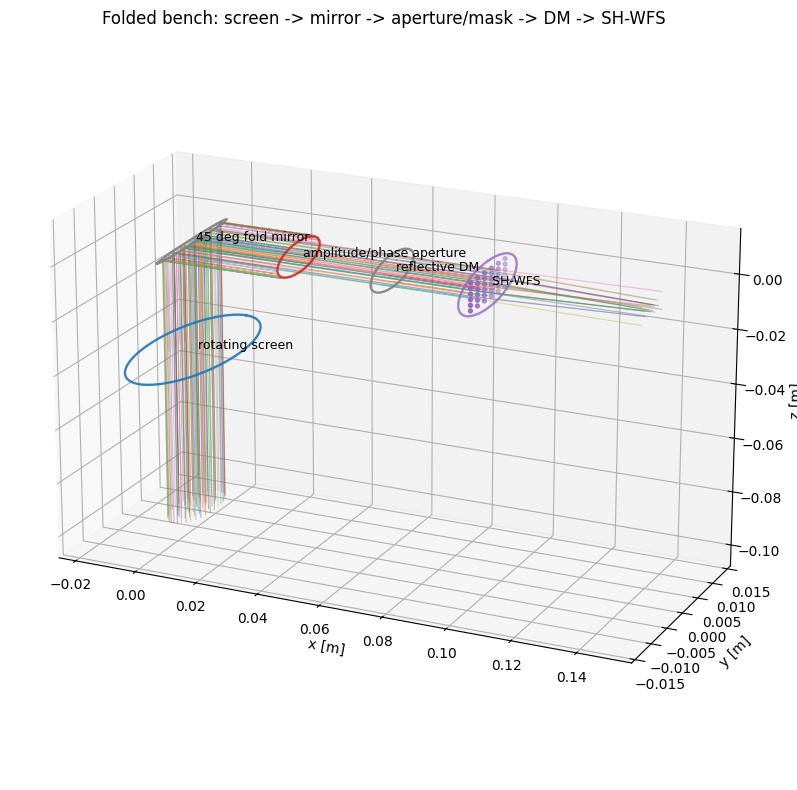

In [14]:
# 3D geometric bench plot

def draw_element_disk(ax, elem, radius=None, color="k", alpha=0.35):
    e1, e2 = elem.plane_basis()
    if radius is None:
        radius = getattr(elem, "clear_radius", None)
    if radius is None:
        radius = getattr(elem, "aperture_radius", 1e-3)

    tt = np.linspace(0, 2*np.pi, 160)
    ring = elem.point[None, :] + radius * (
        np.cos(tt)[:, None] * e1[None, :] + np.sin(tt)[:, None] * e2[None, :]
    )
    ax.plot(ring[:, 0], ring[:, 1], ring[:, 2], color=color, lw=1.7, alpha=alpha)
    ax.text(elem.point[0], elem.point[1], elem.point[2], " " + elem.label, fontsize=9)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

paths, traced = bench.trace_beam(beam, t=t_demo, s_end=0.05)
for path in paths:
    ax.plot(path[:, 0], path[:, 1], path[:, 2], lw=0.8, alpha=0.45)

for elem in bench.elements:
    if isinstance(elem, bt.ShackHartmannWFS3D):
        draw_element_disk(ax, elem, radius=elem.clear_radius, color="tab:purple", alpha=0.8)
        # Draw lenslet centre points
        uu_l, vv_l = elem.lenslet_centres()
        e1, e2 = elem.plane_basis()
        pts = elem.point[None, None, :] + uu_l[..., None] * e1 + vv_l[..., None] * e2
        ax.scatter(pts[..., 0], pts[..., 1], pts[..., 2], s=8, color="tab:purple")
    elif isinstance(elem, bt.Mirror3D):
        draw_element_disk(ax, elem, color="tab:gray", alpha=0.9)
    elif isinstance(elem, bt.DeformableMirror3D):
        draw_element_disk(ax, elem, color="tab:green", alpha=0.9)
    elif isinstance(elem, bt.AmplitudePhaseMask3D):
        draw_element_disk(ax, elem, color="tab:red", alpha=0.9)
    else:
        draw_element_disk(ax, elem, color="tab:blue", alpha=0.9)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("Folded bench: screen -> mirror -> aperture/mask -> DM -> SH-WFS")
ax.set_box_aspect([1.4, 0.6, 0.8])
try:
    ax.view_init(elev=20, azim=-65)
except Exception:
    pass

plt.tight_layout()
plt.show()

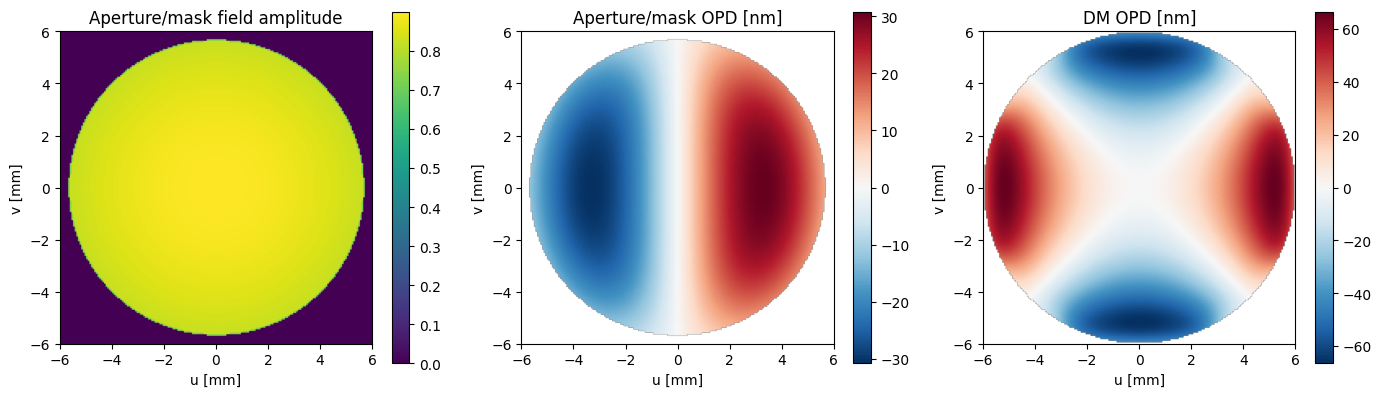

In [7]:
# Inspect mask and DM maps in their local coordinates

# Aperture/mask local amplitude and OPD
test_u = np.linspace(-beam_radius, beam_radius, npix_pupil)
test_v = np.linspace(-beam_radius, beam_radius, npix_pupil)
test_uu, test_vv = np.meshgrid(test_u, test_v)
test_uv = np.stack([test_uu, test_vv], axis=-1)

amp_ap, valid_ap = aperture.sample_amplitude_uv(test_uv)
opd_ap, _ = aperture.sample_uv(test_uv, t=t_demo)

# DM OPD map
opd_dm, valid_dm = dm.sample_uv(test_uv, t=t_demo)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
extent_mm = [test_u.min()*1e3, test_u.max()*1e3, test_v.min()*1e3, test_v.max()*1e3]

im0 = axes[0].imshow(amp_ap, origin="lower", extent=extent_mm)
axes[0].set_title("Aperture/mask field amplitude")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.where(valid_ap, opd_ap*1e9, np.nan), origin="lower", extent=extent_mm, cmap="RdBu_r")
axes[1].set_title("Aperture/mask OPD [nm]")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.where(valid_dm, opd_dm*1e9, np.nan), origin="lower", extent=extent_mm, cmap="RdBu_r")
axes[2].set_title("DM OPD [nm]")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("u [mm]")
    ax.set_ylabel("v [mm]")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [8]:
# Sample wavefronts after selected prefixes of the optical train

wf_screen, samp_screen = sample_wf(
    beam,
    elements=[screen],
    label="after rotating screen",
    t=t_demo,
)

wf_aperture, samp_aperture = sample_wf(
    beam,
    elements=[screen, mirror, aperture],
    label="after mirror + aperture/mask",
    t=t_demo,
)

wf_dm, samp_dm = sample_wf(
    beam,
    elements=[screen, mirror, aperture, dm],
    label="after aperture/mask + DM",
    t=t_demo,
)

wf_sh, samp_sh = sample_wf(
    beam,
    elements=[screen, mirror, aperture, dm, sh],
    label="at SH-WFS plane",
    t=t_demo,
)

print("Power after screen:         ", wavefront_power(wf_screen))
print("Power after aperture/mask:  ", wavefront_power(wf_aperture))
print("Power after DM:             ", wavefront_power(wf_dm))
print("Power at SH plane:          ", wavefront_power(wf_sh))
print("Peak amplitude after screen:", np.nanmax(np.abs(wf_screen.field)))
print("Peak amplitude after mask:  ", np.nanmax(np.abs(wf_aperture.field)))

Power after screen:          4.886771584895662e-05
Power after aperture/mask:   3.5879426272077044e-05
Power after DM:              3.5879426272077044e-05
Power at SH plane:           3.5879426272077044e-05
Peak amplitude after screen: 0.9999451784441781
Peak amplitude after mask:   0.8999457139353143


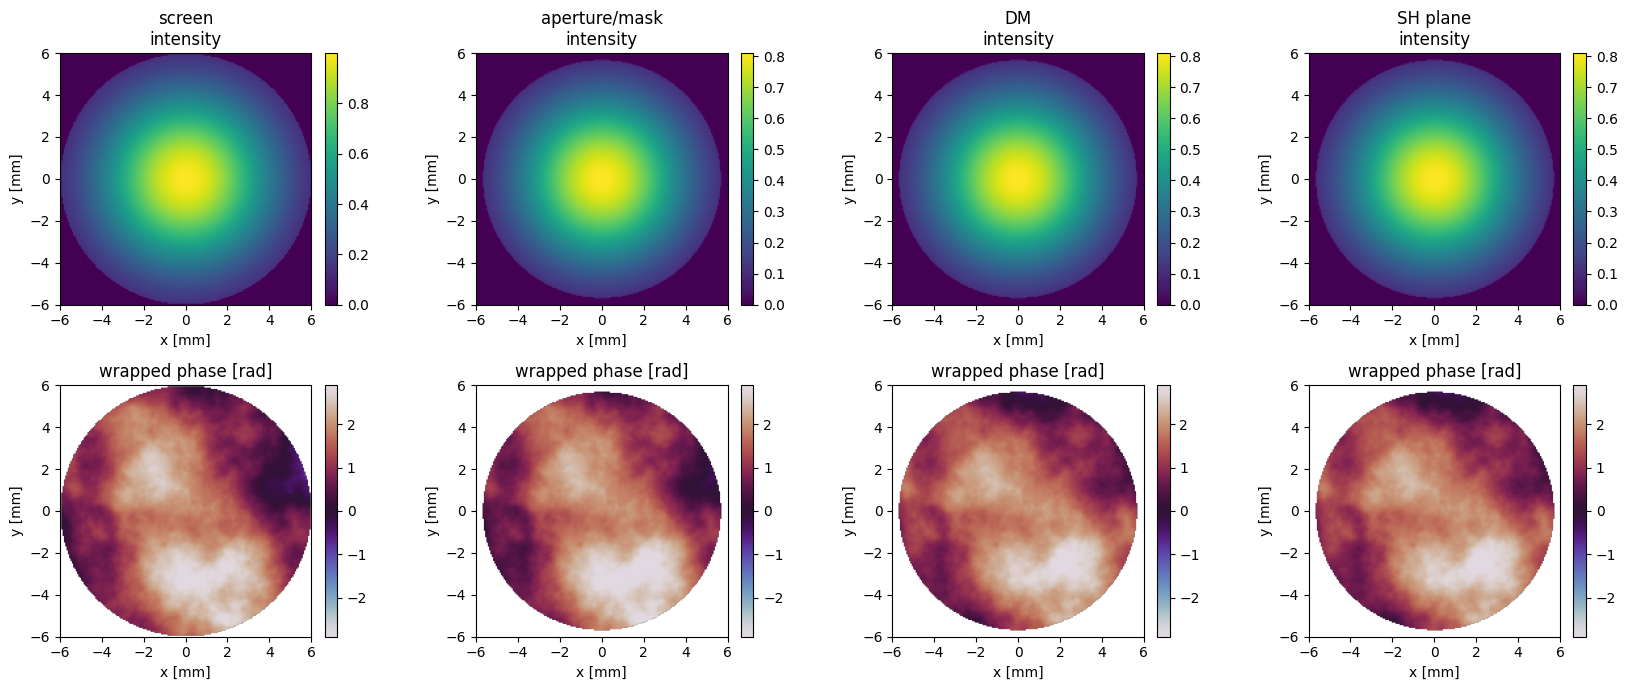

In [9]:
# Visualise intensity and phase at the sampled planes

def plot_wavefront_maps(wfs, titles, phase_percentile=99):
    n = len(wfs)
    fig, axes = plt.subplots(2, n, figsize=(4.2*n, 7), squeeze=False)

    # Use common phase scale.
    phase_vals = []
    for wf in wfs:
        mask = wf.amplitude > 0
        phase_vals.append(np.angle(wf.field)[mask])
    if phase_vals:
        phase_vmax = np.nanpercentile(np.abs(np.concatenate(phase_vals)), phase_percentile)
        if not np.isfinite(phase_vmax) or phase_vmax <= 0:
            phase_vmax = np.pi
    else:
        phase_vmax = np.pi

    for i, (wf, title) in enumerate(zip(wfs, titles)):
        extent = [wf.x.min()*1e3, wf.x.max()*1e3, wf.y.min()*1e3, wf.y.max()*1e3]

        inten = np.abs(wf.field)**2
        phase = np.where(wf.amplitude > 0, np.angle(wf.field), np.nan)

        im0 = axes[0, i].imshow(inten, origin="lower", extent=extent)
        axes[0, i].set_title(title + "\nintensity")
        plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

        im1 = axes[1, i].imshow(phase, origin="lower", extent=extent, cmap="twilight", vmin=-phase_vmax, vmax=phase_vmax)
        axes[1, i].set_title("wrapped phase [rad]")
        plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

        for ax in axes[:, i]:
            ax.set_xlabel("x [mm]")
            ax.set_ylabel("y [mm]")
            ax.set_aspect("equal")

    plt.tight_layout()
    return fig

plot_wavefront_maps(
    [wf_screen, wf_aperture, wf_dm, wf_sh],
    ["screen", "aperture/mask", "DM", "SH plane"],
)
plt.show()

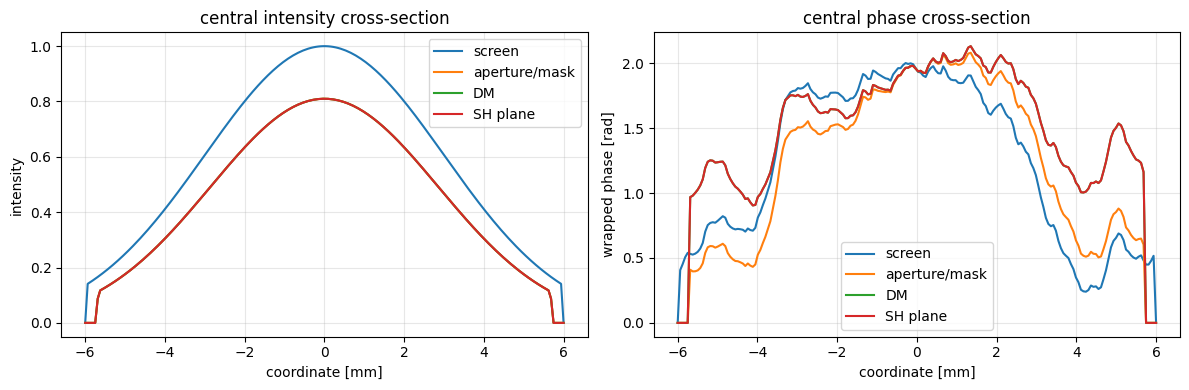

In [10]:
# Centre-line cross sections

mid = npix_pupil // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for wf, label in [
    (wf_screen, "screen"),
    (wf_aperture, "aperture/mask"),
    (wf_dm, "DM"),
    (wf_sh, "SH plane"),
]:
    x_mm = wf.x[mid, :] * 1e3
    intensity = np.abs(wf.field[mid, :])**2
    phase = np.angle(wf.field[mid, :])

    axes[0].plot(x_mm, intensity, label=label)
    axes[1].plot(x_mm, phase, label=label)

axes[0].set_xlabel("coordinate [mm]")
axes[0].set_ylabel("intensity")
axes[0].set_title("central intensity cross-section")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("coordinate [mm]")
axes[1].set_ylabel("wrapped phase [rad]")
axes[1].set_title("central phase cross-section")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Shack-Hartmann spot simulation

def with_field_like(wf, field, label):
    if hasattr(wf, "with_field"):
        out = wf.with_field(field, label=label)
        if out is not None:
            return out

    return Wavefront2D(
        field=field,
        wavelength=wf.wavelength,
        dx=wf.dx,
        dy=wf.dy,
        x=wf.x,
        y=wf.y,
        label=label,
        metadata={**getattr(wf, "metadata", {}), "source": "with_field_like"},
    )


def lenslet_focal_spot(wf, lenslet_mask, focal_length_m, pad_to=256):
    """
    Propagate one lenslet subaperture to its focal spot.

    Uses the module's scaled focal-plane propagation if available, otherwise
    falls back to FFT PSF intensity.
    """
    sub = with_field_like(wf, wf.field * lenslet_mask, label=wf.label + " subaperture")

    if pad_to is not None:
        try:
            sub = wave_optics.pad_wavefront(sub, pad_to=pad_to)
        except Exception:
            pass

    try:
        foc = wave_optics.lens_focal_plane(
            sub,
            focal_length=focal_length_m,
            include_global_phase=False,
            label=sub.label + " focal spot",
        )
        spot = np.abs(foc.field)**2
    except Exception:
        # Fallback: Fraunhofer PSF.
        spot = psf_tools.psf_from_wavefront(sub, pad_to=pad_to, normalize=None)

    return spot


def simulate_shwfs_detector(
    wf,
    sh,
    spot_pad=256,
    cell_pixels=None,
    normalize=False,
):
    """
    Assemble a SH-WFS detector image by propagating each lenslet subaperture.
    """
    if cell_pixels is None:
        cell_pixels = sh.pixels_per_lenslet

    det = np.zeros(sh.detector_shape, dtype=float)
    spot_info = {}

    ny_l, nx_l = sh.n_lenslets

    for iy in range(ny_l):
        for ix in range(nx_l):
            if not sh.valid_lenslet_mask[iy, ix]:
                continue

            lens_mask = sh.lenslet_mask_for_grid(wf.x, wf.y, (iy, ix))
            lens_mask = lens_mask & (wf.amplitude > 0)

            if not np.any(lens_mask):
                continue

            spot = lenslet_focal_spot(
                wf,
                lens_mask,
                focal_length_m=sh.focal_length_m,
                pad_to=spot_pad,
            )

            cell = center_crop_or_pad(spot, cell_pixels)

            xs, xe, ys, ye = sh.detector_cell_bounds((iy, ix))
            det[ys:ye, xs:xe] += cell

            xp, yp = local_centroid(cell)
            spot_info[(iy, ix)] = {
                "flux": float(np.sum(cell)),
                "x_centroid_cell": xp,
                "y_centroid_cell": yp,
            }

    if normalize and np.nanmax(det) > 0:
        det = det / np.nanmax(det)

    return det, spot_info


sh_fft_pad = 256

det_screen, info_screen = simulate_shwfs_detector(
    wf_screen,
    sh,
    spot_pad=sh_fft_pad,
    normalize=False,
)

det_aperture, info_aperture = simulate_shwfs_detector(
    wf_aperture,
    sh,
    spot_pad=sh_fft_pad,
    normalize=False,
)

det_dm, info_dm = simulate_shwfs_detector(
    wf_dm,
    sh,
    spot_pad=sh_fft_pad,
    normalize=False,
)

print("Detector sums:")
print("  screen:        ", np.sum(det_screen))
print("  aperture/mask: ", np.sum(det_aperture))
print("  DM:            ", np.sum(det_dm))
print("Number of spots:", len(info_dm))

Detector sums:
  screen:         34639556.23888585
  aperture/mask:  25278255.87317725
  DM:             25287707.941749856
Number of spots: 32


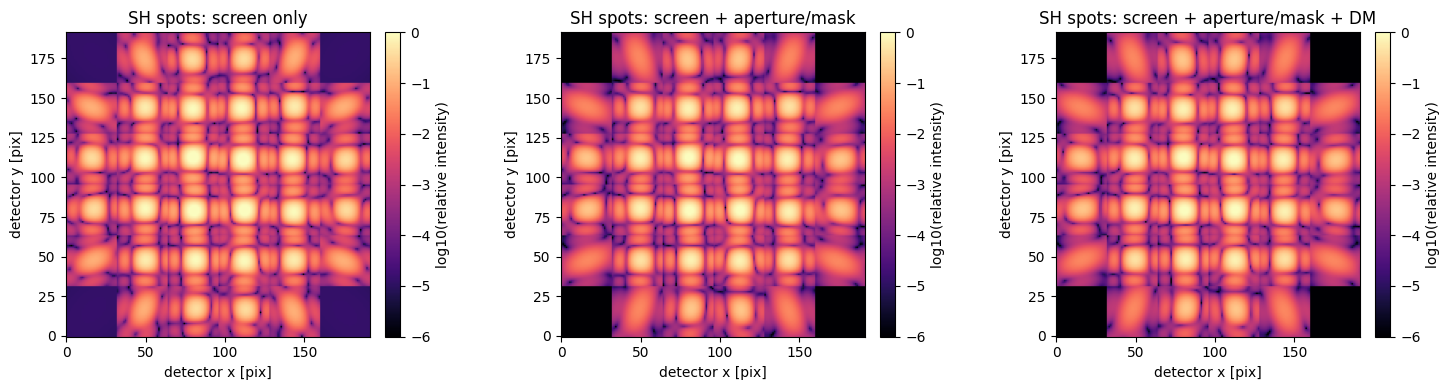

In [12]:
# Display SH-WFS spot images

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

images = [
    (det_screen, "SH spots: screen only"),
    (det_aperture, "SH spots: screen + aperture/mask"),
    (det_dm, "SH spots: screen + aperture/mask + DM"),
]

# Use a common log scale.
all_vals = np.concatenate([img.ravel() for img, _ in images])
vmax = np.nanpercentile(all_vals[all_vals > 0], 99.8) if np.any(all_vals > 0) else 1.0

for ax, (img, title) in zip(axes, images):
    show = np.log10(np.maximum(img / vmax, 1e-6))
    im = ax.imshow(show, origin="lower", cmap="magma", vmin=-6, vmax=0)
    ax.set_title(title)
    ax.set_xlabel("detector x [pix]")
    ax.set_ylabel("detector y [pix]")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="log10(relative intensity)")

plt.tight_layout()
plt.show()

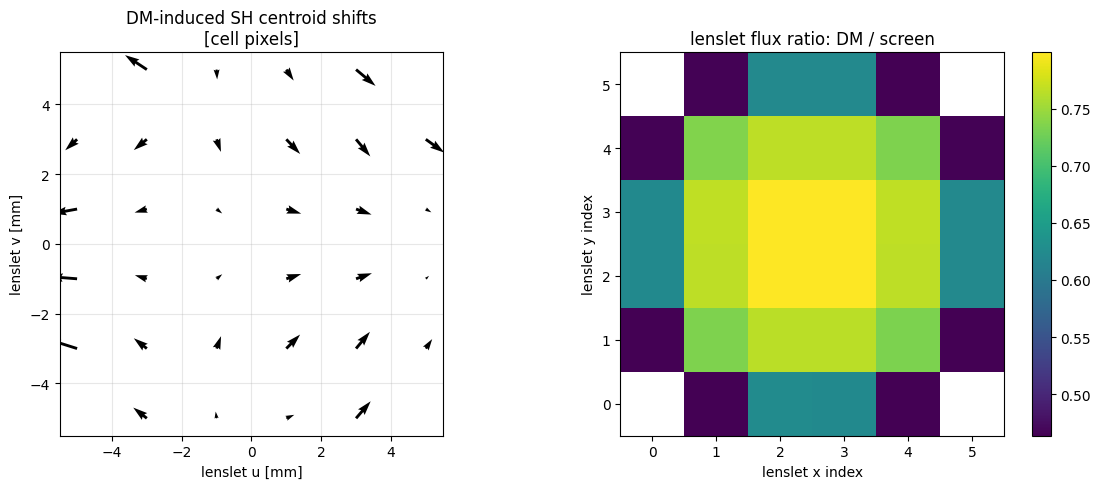

median centroid shift [pix]: 0.46797803573130514


In [13]:
# Spot centroid shifts relative to the screen-only case

def centroid_arrays(info, sh):
    ny, nx = sh.n_lenslets
    X = np.full((ny, nx), np.nan)
    Y = np.full((ny, nx), np.nan)
    F = np.full((ny, nx), np.nan)

    for (iy, ix), d in info.items():
        X[iy, ix] = d["x_centroid_cell"]
        Y[iy, ix] = d["y_centroid_cell"]
        F[iy, ix] = d["flux"]

    return X, Y, F


xs0, ys0, f0 = centroid_arrays(info_screen, sh)
xs1, ys1, f1 = centroid_arrays(info_dm, sh)

dx_cent = xs1 - xs0
dy_cent = ys1 - ys0

uu_l, vv_l = sh.lenslet_centres()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].quiver(
    uu_l * 1e3,
    vv_l * 1e3,
    dx_cent,
    dy_cent,
    angles="xy",
    scale_units="xy",
    scale=1.0,
)
axes[0].set_title("DM-induced SH centroid shifts\n[cell pixels]")
axes[0].set_xlabel("lenslet u [mm]")
axes[0].set_ylabel("lenslet v [mm]")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

flux_ratio = np.where(f0 > 0, f1 / f0, np.nan)
im = axes[1].imshow(flux_ratio, origin="lower")
axes[1].set_title("lenslet flux ratio: DM / screen")
axes[1].set_xlabel("lenslet x index")
axes[1].set_ylabel("lenslet y index")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print("median centroid shift [pix]:", np.nanmedian(np.sqrt(dx_cent**2 + dy_cent**2)))